# Erwerb des Schweizer Bürgerrechts nach Nationalität, Geschlecht und Altersgruppe

### Kurzbeschreibung
Anzahl Einbürgerungen nach bisheriger Staatsangehörigkeit, Geschlecht, Altersgruppe und Jahr.

Die bisherige Staatsangehörigkeit einer Person wird hier nach der Nomenklatur des Bundesamts für Statistik (BFS) angegeben. Dabei werden die entsprechenden Regionen und Kontinente mitgeliefert. Die Altersgruppen werden als 20-Jahresklassen angegeben.

Datum: 07.03.2024


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_brw_erwerb-ch-buergerrecht_nat_geschl_ag_od3600

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_brw_erwerb-ch-buergerrecht_nat_geschl_ag_od3600


### Importiere die notwendigen Packages

In [47]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [1]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [2]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [5]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [6]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [7]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [8]:
package_name = "bev_brw_erwerb-ch-buergerrecht_nat_geschl_ag_od3600"

In [9]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'dropzone'
    , package_name = package_name
    , dataset_name = "BEV360OD3600"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH\bev_brw_erwerb-ch-buergerrecht_nat_geschl_ag_od3600\BEV360OD3600.csv


data_source: dropzone


In [10]:
data2betested.head(2).T

,0,1
StichtagDatJahr,2024-01-01 00:00:00,2024-01-01 00:00:00
NationBisherHistSort,8354,8239
NationBisherHistLang,Togo,Türkei
NationBisherSort,8354,8239
NationBisherLang,Togo,Türkei
RegionBisherSort,24,16
RegionBisherLang,Westafrika,Südeuropa
KontinentBisherSort,2,1
KontinentBisherLang,Afrika,Europa
SexKurz,M,M


Berechne weitere Attribute falls notwendig

In [11]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr         datetime64[ns]
NationBisherHistSort             int64
NationBisherHistLang            object
NationBisherSort                 int64
NationBisherLang                object
RegionBisherSort                 int64
RegionBisherLang                object
KontinentBisherSort              int64
KontinentBisherLang             object
SexKurz                         object
AlterV20Sort                     int64
AlterV20Kurz                    object
AnzEinbWir                       int64
StichtagDatJahr_str             object
Jahr                    datetime64[ns]
Jahr_end                datetime64[ns]
Jahr_nbr                         int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [12]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2024


In [13]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993-12-31 und ein Maximumjahr von 2024-12-31


### Einfache Datentests

In [14]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 13000 entries, 0 to 12999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   StichtagDatJahr       13000 non-null  datetime64[ns]
 1   NationBisherHistSort  13000 non-null  int64         
 2   NationBisherHistLang  13000 non-null  object        
 3   NationBisherSort      13000 non-null  int64         
 4   NationBisherLang      13000 non-null  object        
 5   RegionBisherSort      13000 non-null  int64         
 6   RegionBisherLang      13000 non-null  object        
 7   KontinentBisherSort   13000 non-null  int64         
 8   KontinentBisherLang   13000 non-null  object        
 9   SexKurz               13000 non-null  object        
 10  AlterV20Sort          13000 non-null  int64         
 11  AlterV20Kurz          13000 non-null  object        
 12  AnzEinbWir            13000 non-null  int64         
 13  StichtagDatJahr_str  

In [15]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 13,000 rows (observations) and 17 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [16]:
data2betested.describe()

,StichtagDatJahr,NationBisherHistSort,NationBisherSort,RegionBisherSort,KontinentBisherSort,AlterV20Sort,AnzEinbWir,Jahr,Jahr_end,Jahr_nbr
count,13000,13000,13000,13000,13000,13000,13000,13000,13000,13000
mean,2009-11-18 13:04:34.707692288,8352,8352,27,2,2,7,2009-11-18 13:04:34.707692288,2010-11-17 19:10:26.953846272,2010
min,1993-01-01 00:00:00,8201,8201,11,1,1,0,1993-01-01 00:00:00,1993-12-31 00:00:00,1993
25%,2003-01-01 00:00:00,8236,8236,15,1,1,1,2003-01-01 00:00:00,2003-12-31 00:00:00,2003
50%,2011-01-01 00:00:00,8320,8320,22,2,2,2,2011-01-01 00:00:00,2011-12-31 00:00:00,2011
75%,2017-04-02 06:00:00,8439,8439,36,3,3,5,2017-04-02 06:00:00,2018-04-01 06:00:00,2017
max,2024-01-01 00:00:00,8999,8999,88,8,5,402,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,131,131,14,1,1,20,NaN,NaN,9


Welches sind die Quartiere ohne Werte bei BEW?

In [17]:
data2betested[np.isnan(data2betested.AnzEinbWir)]

,StichtagDatJahr,NationBisherHistSort,NationBisherHistLang,NationBisherSort,NationBisherLang,RegionBisherSort,RegionBisherLang,...,AlterV20Sort,AlterV20Kurz,AnzEinbWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [18]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [19]:
data2betested.index.year.unique()

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [20]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,NationBisherHistLang,NationBisherLang,RegionBisherLang,KontinentBisherLang,SexKurz,AlterV20Kurz,StichtagDatJahr_str,Jahr,Jahr_end
count,13000,13000,13000,13000,13000,13000,13000,13000,13000
unique,167,165,30,6,2,5,32,NaN,NaN
top,Deutschland,Deutschland,Südosteuropa,Europa,M,20-39,2019-01-01,NaN,NaN
freq,272,272,1588,5695,6618,4405,535,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-11-18 13:04:34.707692288,2010-11-17 19:10:26.953846272
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993-01-01 00:00:00,1993-12-31 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-01 00:00:00,2003-12-31 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-01 00:00:00,2011-12-31 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-04-02 06:00:00,2018-04-01 06:00:00
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:00:00,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [21]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,NationBisherHistSort,NationBisherSort,RegionBisherSort,KontinentBisherSort,AlterV20Sort,AnzEinbWir,Jahr_nbr
count,"13,000","13,000","13,000","13,000","13,000","13,000","13,000"
mean,"8,352","8,352",27,2,2,7,"2,010"
std,131,131,14,1,1,20,9
min,"8,201","8,201",11,1,1,0,"1,993"
25%,"8,236","8,236",15,1,1,1,"2,003"
50%,"8,320","8,320",22,2,2,2,"2,011"
75%,"8,439","8,439",36,3,3,5,"2,017"
max,"8,999","8,999",88,8,5,402,"2,024"


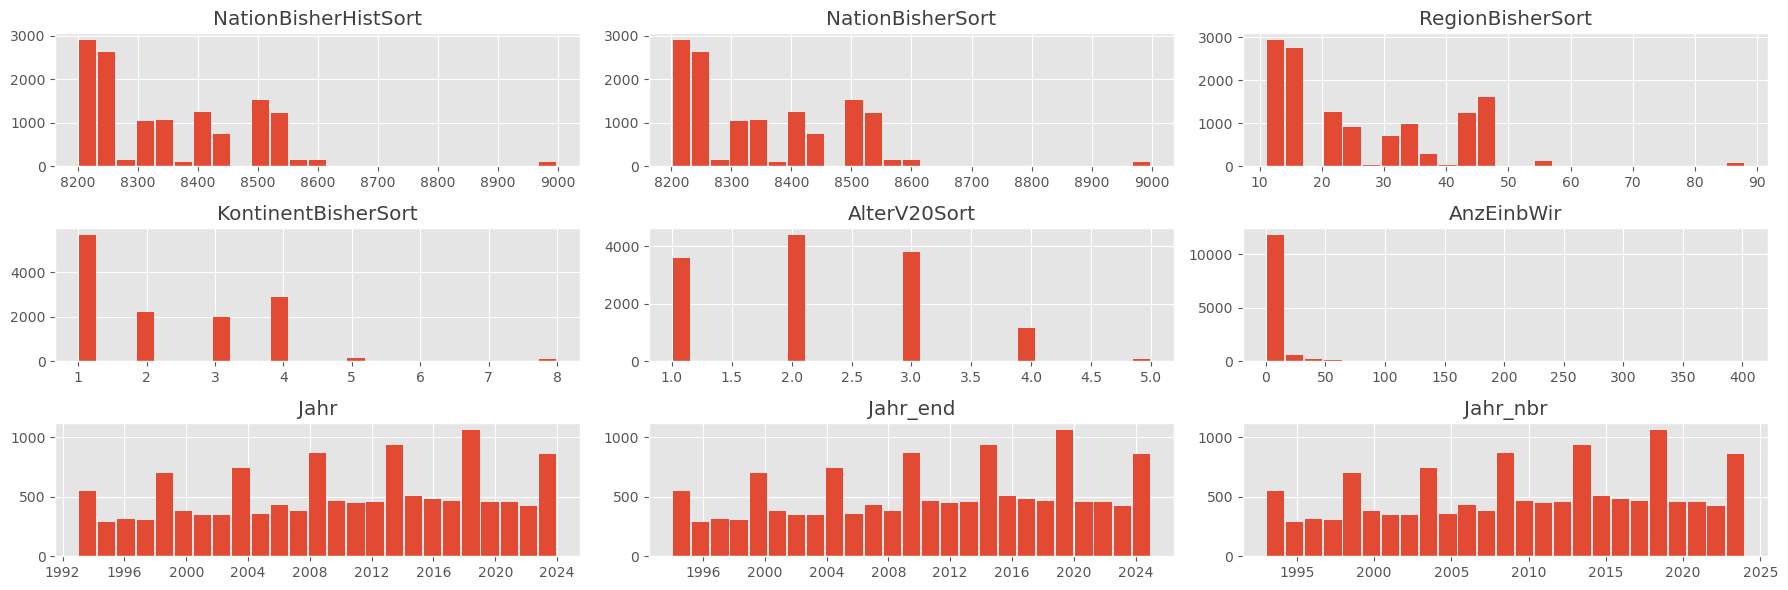

In [22]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [23]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,NationBisherHistSort,NationBisherHistLang,NationBisherSort,NationBisherLang,RegionBisherSort,RegionBisherLang,KontinentBisherSort,...,AlterV20Sort,AlterV20Kurz,AnzEinbWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [24]:
data2betested.isnull().sum()

NationBisherHistSort    0
NationBisherHistLang    0
NationBisherSort        0
NationBisherLang        0
RegionBisherSort        0
RegionBisherLang        0
KontinentBisherSort     0
KontinentBisherLang     0
SexKurz                 0
AlterV20Sort            0
AlterV20Kurz            0
AnzEinbWir              0
StichtagDatJahr_str     0
Jahr                    0
Jahr_end                0
Jahr_nbr                0
dtype: int64

In [25]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [26]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzEinbWir
0,2024-01-01,2024,2024-12-31,3632
1,2023-01-01,2023,2023-12-31,2950
2,2022-01-01,2022,2022-12-31,3297


In [27]:
agg_nation = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['NationBisherHistSort', 'NationBisherHistLang', 'NationBisherSort','NationBisherLang']) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('NationBisherSort', ascending=True) 
agg_nation.reset_index().head(8)

,NationBisherHistSort,NationBisherHistLang,NationBisherSort,NationBisherLang,sum_AnzEinbWir
0,8201,Albanien,8201,Albanien,105
1,8204,Belgien,8204,Belgien,200
2,8205,Bulgarien,8205,Bulgarien,339
3,8206,Dänemark,8206,Dänemark,109
4,8207,Deutschland,8207,Deutschland,15480
5,8211,Finnland,8211,Finnland,183
6,8212,Frankreich,8212,Frankreich,1608
7,8214,Griechenland,8214,Griechenland,1271


In [28]:
agg_region = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['RegionBisherSort', 'RegionBisherLang',]) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('RegionBisherSort', ascending=True) 
agg_region.reset_index().head(8)

,RegionBisherSort,RegionBisherLang,sum_AnzEinbWir
0,11,Nordeuropa,735
1,12,Osteuropa,1529
2,13,Zentraleuropa,18870
3,14,Westeuropa,3497
4,15,Südwesteuropa,4672
5,16,Südeuropa,16765
6,17,Südosteuropa,23614
7,21,Nordafrika,1646


In [29]:
agg_kont = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['KontinentBisherSort', 'KontinentBisherLang']) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('KontinentBisherSort', ascending=True) 
agg_kont.reset_index().head(8)

,KontinentBisherSort,KontinentBisherLang,sum_AnzEinbWir
0,1,Europa,69682
1,2,Afrika,5066
2,3,Amerika,5488
3,4,Asien,12978
4,5,Ozeanien,190
5,8,Unzuteilbar,114


In [30]:
agg_sex = data2betested.loc[data_min_date:data_max_date]\
    .groupby([ 'SexKurz',]) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('SexKurz', ascending=True) 
agg_sex.reset_index().head(8)

,SexKurz,sum_AnzEinbWir
0,M,46518
1,W,47000


In [31]:
agg_ag = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterV20Sort', 'AlterV20Kurz',]) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('AlterV20Sort', ascending=True) 
agg_ag.reset_index().head(8)

,AlterV20Sort,AlterV20Kurz,sum_AnzEinbWir
0,1,0-19,32241
1,2,20-39,30064
2,3,40-59,27933
3,4,60-79,3195
4,5,80-99,85


### Pivotiere

In [32]:
data2betested.columns

Index(['NationBisherHistSort', 'NationBisherHistLang', 'NationBisherSort', 'NationBisherLang',
       'RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort', 'KontinentBisherLang',
       'SexKurz', 'AlterV20Sort', 'AlterV20Kurz', 'AnzEinbWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [33]:
pivoted_df = data2betested.pivot_table(
    index='Jahr_nbr',
    columns= ('KontinentBisherLang','SexKurz'),
    values='AnzEinbWir',
    aggfunc='sum'
)

pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
pivoted_df = pivoted_df.sort_index(ascending=False)

# Anzeigen des Ergebnisses
pivoted_df.head(8).T

Jahr_nbr                     2024  2023  2022  2021  2020  2019  2018  2017
KontinentBisherLang SexKurz                                                
Europa              W        1562  1224  1421  1514  1320  1555  1513  1273
                    M        1482  1184  1330  1490  1313  1571  1505  1207
Asien               W         120   105    90   124   133   222   243   204
Afrika              M         112   106   102   104    95   133   123   129
Asien               M         101    92    86   143   124   221   250   254
Amerika             W          93    93   105    95    93   147   146   131
                    M          72    59    76    70    82   115   103    77
Afrika              W          70    78    78    81    99   116    86   100
Unzuteilbar         M           8     1     2     2   NaN     7     3     2
Ozeanien            M           4     2     2     2     6     3     3    11
                    W           4     3     4     6     5     4     4     8
Unzuteilbar         W           4     3     1     1     1   NaN     2     1

In [34]:
pivoted_df_diff = pivoted_df.sort_index(ascending=True).diff()
pivoted_df_diff.tail(5)

KontinentBisherLang Europa      Asien Afrika Asien Amerika     Afrika Unzuteilbar Ozeanien     \
SexKurz                  W    M     W      M     M       W   M      W           M        M  W   
Jahr_nbr                                                                                        
2020                  -235 -258   -89    -38   -97     -54 -33    -17         NaN        3  1   
2021                   194  177    -9      9    19       2 -12    -18         NaN       -4  1   
2022                   -93 -160   -34     -2   -57      10   6     -3           0        0 -2   
2023                  -197 -146    15      4     6     -12 -17      0          -1        0 -1   
2024                   338  298    15      6     9       0  13     -8           7        2  1   

KontinentBisherLang Unzuteilbar  
SexKurz                       W  
Jahr_nbr                         
2020                        NaN  
2021                          0  
2022                          0  
2023                          2  
2024                          1

### Visualisierungen nach Zeitausschnitten

#### Entwicklung Einbürgerungen nach Kontinent

In [35]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_end', 'Jahr_nbr','KontinentBisherSort', 'KontinentBisherLang']) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('KontinentBisherSort', ascending=True) 
myAgg1.reset_index().head(3)

,Jahr,Jahr_end,Jahr_nbr,KontinentBisherSort,KontinentBisherLang,sum_AnzEinbWir
0,1994-01-01,1994-12-31,1994,1,Europa,910
1,2020-01-01,2020-12-31,2020,1,Europa,2633
2,2012-01-01,2012-12-31,2012,1,Europa,2293


In [36]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('KontinentBisherSort', ascending=True)
    ,x = 'Jahr:T'
    ,y = 'sum_AnzEinbWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "KontinentBisherLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung Einbürgerungen nach Kontinent, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung nach Region

In [37]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_end', 'Jahr_nbr','RegionBisherSort', 'RegionBisherLang',]) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('RegionBisherSort', ascending=True) 

myAgg2.reset_index().head(3)

,Jahr,Jahr_end,Jahr_nbr,RegionBisherSort,RegionBisherLang,sum_AnzEinbWir
0,1994-01-01,1994-12-31,1994,11,Nordeuropa,5
1,2005-01-01,2005-12-31,2005,11,Nordeuropa,10
2,1995-01-01,1995-12-31,1995,11,Nordeuropa,6


In [38]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('RegionBisherSort', ascending=True)
    ,x = 'Jahr:T'
    ,y = 'sum_AnzEinbWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "RegionBisherLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung Einbürgerungen nach Region, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

##### Kombinierte Grafik in Altair

In [39]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik2)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik2,  spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

In [40]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'NationBisherHistSort', 'NationBisherHistLang', 'NationBisherSort',
       'NationBisherLang', 'RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort',
       'KontinentBisherLang', 'SexKurz', 'AlterV20Sort', 'AlterV20Kurz', 'AnzEinbWir',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

#### Barcharts mit Seaborn

In [41]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested.loc[data_min_jahr:data_max_jahr]\
    .groupby(['StichtagDatJahr','Jahr', 'Jahr_end', 'Jahr_nbr','AlterV20Sort', 'AlterV20Kurz']) \
    .agg(sum_WBev=('AnzEinbWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAggBar.reset_index().head(3)

,StichtagDatJahr,Jahr,Jahr_end,Jahr_nbr,AlterV20Sort,AlterV20Kurz,sum_WBev
0,1993-01-01,1993-01-01,1993-12-31,1993,1,0-19,191
1,1993-01-01,1993-01-01,1993-12-31,1993,2,20-39,450
2,1993-01-01,1993-01-01,1993-12-31,1993,3,40-59,448


In [42]:
#help(sns.catplot)   
# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

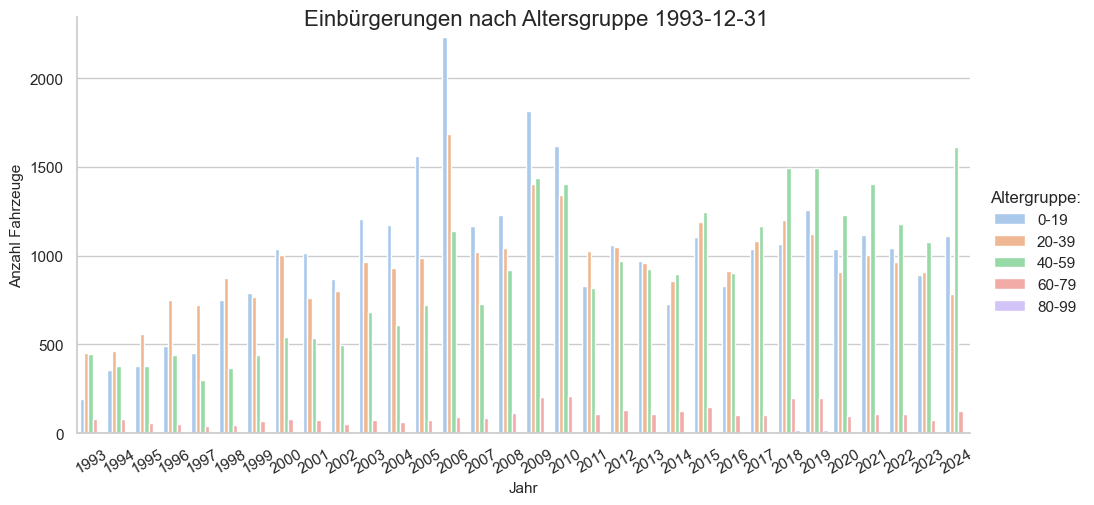

In [43]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Jahr_nbr"
            , y="sum_WBev"
            , hue="AlterV20Kurz"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.reset_index()
           )


myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)

myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Anzahl Fahrzeuge', fontsize=11)

# Titel hinzufügen
myHist.fig.suptitle('Einbürgerungen nach Altersgruppe '+data_min_date, fontsize=16)
# Legende anpassen
myHist.legend.set_title('Altergruppe:')
# Layout anpassen
#plt.tight_layout()
# Plot anzeigen
plt.show()

##### Stacked Bar Chart

In [44]:
myAggBar.reset_index().head(2)

,StichtagDatJahr,Jahr,Jahr_end,Jahr_nbr,AlterV20Sort,AlterV20Kurz,sum_WBev
0,1993-01-01,1993-01-01,1993-12-31,1993,1,0-19,191
1,1993-01-01,1993-01-01,1993-12-31,1993,2,20-39,450


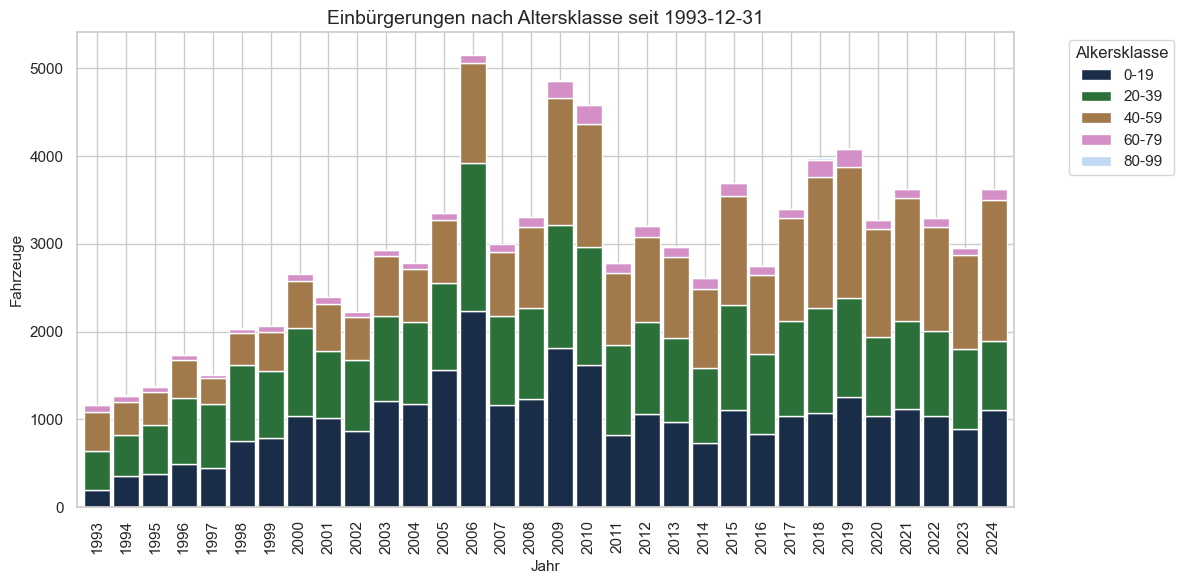

In [45]:
# Daten vorbereiten

data = myAggBar.query("sum_WBev > 0").reset_index()
data_pivoted = data.pivot(index='Jahr_nbr', columns='AlterV20Kurz', values='sum_WBev').fillna(0)

# Farbpalette erstellen
colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Einbürgerungen nach Altersklasse seit '+data_min_date, fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Fahrzeuge', fontsize=11)

# Legende anpassen
plt.legend(title='Alkersklasse', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Faced Grids

In [48]:
data2betested.columns

Index(['NationBisherHistSort', 'NationBisherHistLang', 'NationBisherSort', 'NationBisherLang',
       'RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort', 'KontinentBisherLang',
       'SexKurz', 'AlterV20Sort', 'AlterV20Kurz', 'AnzEinbWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [53]:
myFG = data2betested.query('NationBisherLang !="Schweiz"')\
    .groupby(['StichtagDatJahr', 'Jahr','Jahr_end', 'Jahr_nbr', 'NationBisherSort', 'NationBisherLang', 'RegionBisherSort', 'RegionBisherLang','KontinentBisherSort', 'KontinentBisherLang']) \
    .agg(sum_WBev=('AnzEinbWir', 'sum')) \
    .sort_values('NationBisherSort', ascending=True) 
myFG.reset_index().head(3)

,StichtagDatJahr,Jahr,Jahr_end,Jahr_nbr,NationBisherSort,NationBisherLang,RegionBisherSort,RegionBisherLang,KontinentBisherSort,KontinentBisherLang,sum_WBev
0,2022-01-01,2022-01-01,2022-12-31,2022,8201,Albanien,17,Südosteuropa,1,Europa,1
1,2011-01-01,2011-01-01,2011-12-31,2011,8201,Albanien,17,Südosteuropa,1,Europa,4
2,1994-01-01,1994-01-01,1994-12-31,1994,8201,Albanien,17,Südosteuropa,1,Europa,2


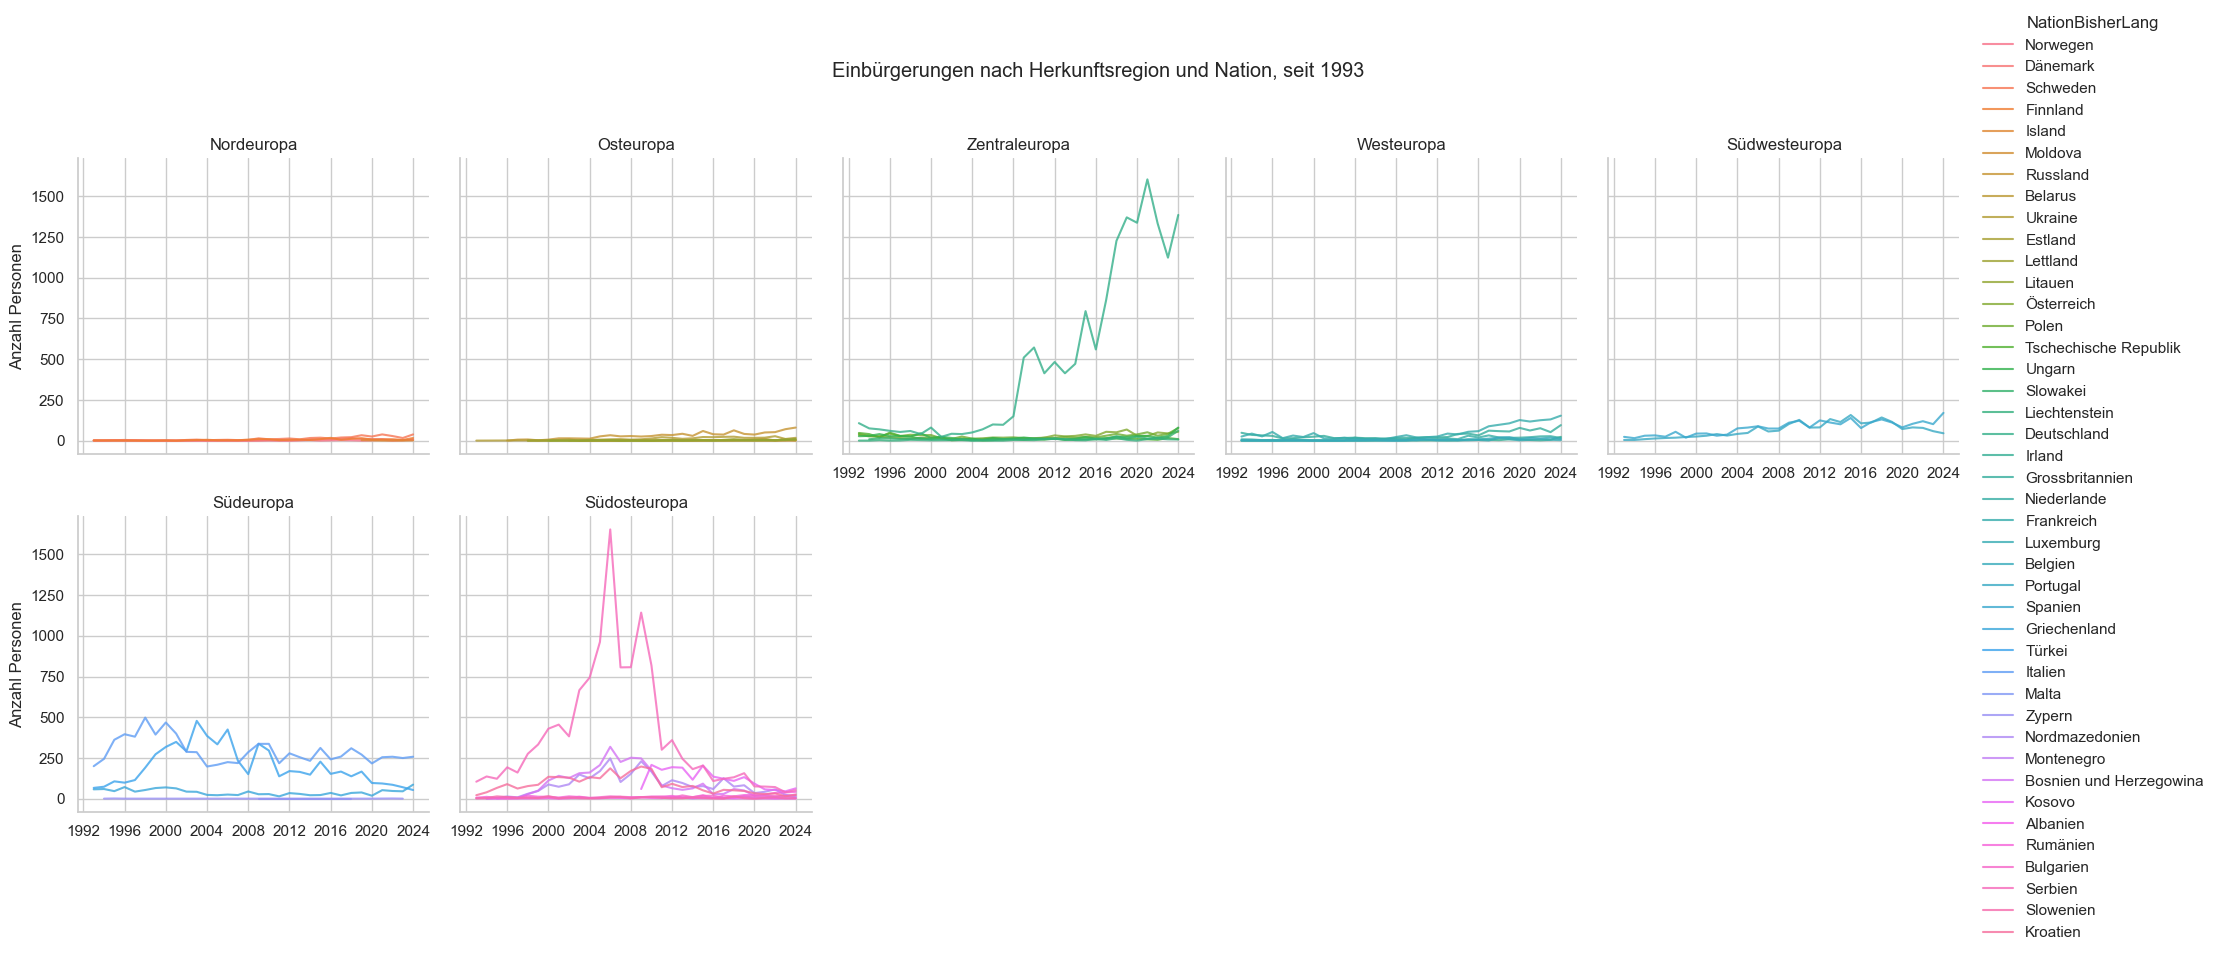

In [54]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().query("KontinentBisherSort==1").sort_values('RegionBisherSort', ascending=True)
    ,col = "RegionBisherLang"
    ,hue = "NationBisherLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Einbürgerungen nach Herkunftsregion und Nation, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

##### Einbürgerungen nach Altersgruppe und Herkunft

In [55]:
data2betested.columns

Index(['NationBisherHistSort', 'NationBisherHistLang', 'NationBisherSort', 'NationBisherLang',
       'RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort', 'KontinentBisherLang',
       'SexKurz', 'AlterV20Sort', 'AlterV20Kurz', 'AnzEinbWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [59]:
myFG2 = data2betested.query('KontinentBisherSort ==1')\
    .groupby(['StichtagDatJahr', 'Jahr','Jahr_end', 'Jahr_nbr', 
    'NationBisherSort', 'NationBisherLang','RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort', 'KontinentBisherLang',
    'AlterV20Sort', 'AlterV20Kurz',]) \
    .agg(sum_WBev=('AnzEinbWir', 'sum')) \
    .sort_values('NationBisherSort', ascending=True) 
myFG2.reset_index().head(3)

,StichtagDatJahr,Jahr,Jahr_end,Jahr_nbr,NationBisherSort,NationBisherLang,RegionBisherSort,RegionBisherLang,KontinentBisherSort,KontinentBisherLang,AlterV20Sort,AlterV20Kurz,sum_WBev
0,2007-01-01,2007-01-01,2007-12-31,2007,8201,Albanien,17,Südosteuropa,1,Europa,1,0-19,3
1,2002-01-01,2002-01-01,2002-12-31,2002,8201,Albanien,17,Südosteuropa,1,Europa,1,0-19,2
2,2002-01-01,2002-01-01,2002-12-31,2002,8201,Albanien,17,Südosteuropa,1,Europa,2,20-39,1


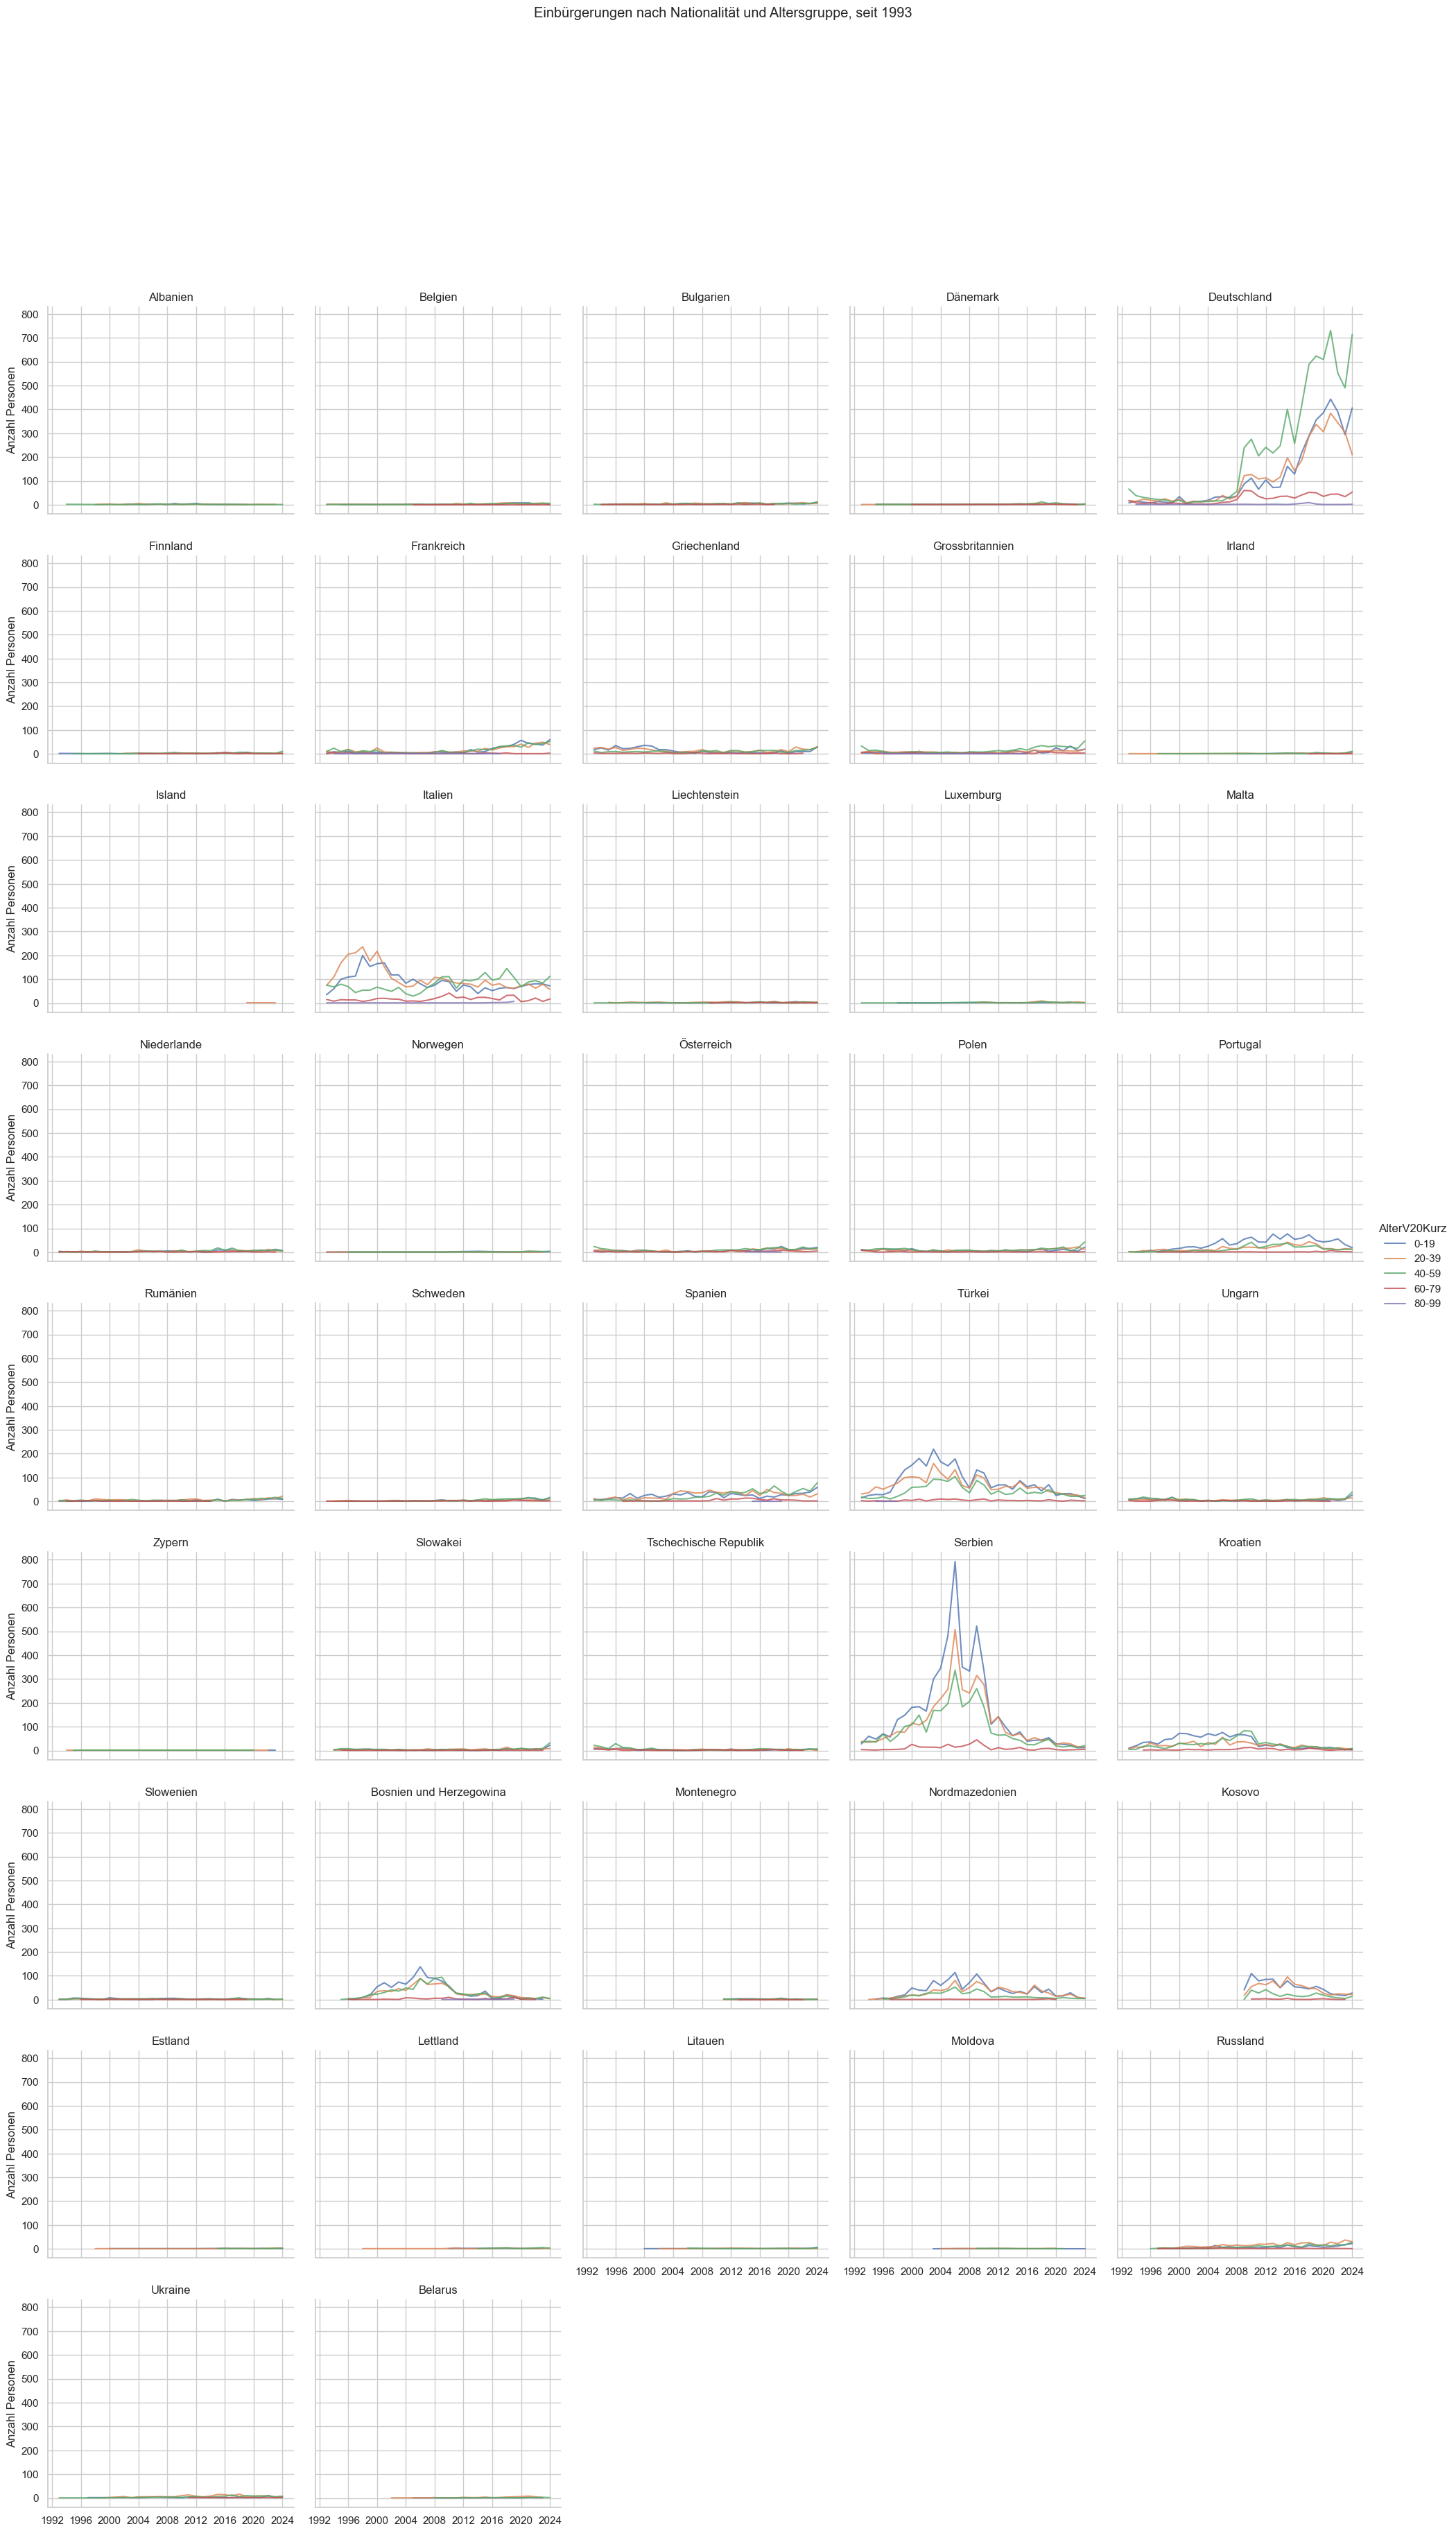

In [60]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = myFG2.reset_index().sort_values('NationBisherSort', ascending=True)
    ,col = "NationBisherLang"
    ,hue = "AlterV20Kurz"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Einbürgerungen nach Nationalität und Altersgruppe, seit "+str(int(data2betested.index.year.min()))
)
faced_grid2

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [61]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [64]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['RegionBisherLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Nordafrika': '#0017BF', 'Zentraleuropa': '#0072D7', 'Westeuropa': '#00A5D2', 'Südosteuropa': '#5E359A', 'Westafrika': '#BA0062', 'Ostafrika': '#DA5563', 'Zentralafrika': '#00615D', 'Südeuropa': '#00770F', 'Nordeuropa': '#7BA600', 'Südwesteuropa': '#7B4100', 'Ostasien': '#DC5500', 'Südostafrika': '#DA9C00', 'Südafrika': '#5D4BFE', 'Mittleres Südamerika': '#4AA9FF', 'Südliches Südamerika': '#55FFFF', 'Zentralamerika': '#986AD5', 'Nördliches Südamerika': '#FC4C99', 'Karibik': '#FF919A', 'Nordamerika': '#349894', 'Südasien': '#44B14A', 'Westasien': '#B7E14E', 'Südostasien': '#B97624', 'Südliches Ozeanien': '#FF7231', 'Unzuteilbar': '#FFD736', 'Osteuropa': '#3431DE', 'Südwestafrika': '#0A8DF6', 'Mittleres Ozeanien': '#23C3F1', 'Zentralasien': '#7B4FB7', 'Südwestasien': '#DB247D', 'Nördliches Asien': '#FB737E'}


##### Einbürgerungen nach Herkunftsgebiet

In [86]:
myTM = data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2024)].reset_index()  \
    .query('NationBisherHistSort != 0') \
    .groupby(['StichtagDatJahr','Jahr_end', 'Jahr_nbr', 'NationBisherSort', 'NationBisherLang',
       'RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort', 'KontinentBisherLang']) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('sum_AnzEinbWir', ascending=False) 

myTM.reset_index().head(2)

,StichtagDatJahr,Jahr_end,Jahr_nbr,NationBisherSort,NationBisherLang,RegionBisherSort,RegionBisherLang,KontinentBisherSort,KontinentBisherLang,sum_AnzEinbWir
0,2024-01-01,2024-12-31,2024,8207,Deutschland,13,Zentraleuropa,1,Europa,1385
1,2004-01-01,2004-12-31,2004,8248,Serbien,17,Südosteuropa,1,Europa,743


In [113]:
myTM = myTM
print (myTM.reset_index().Jahr_nbr.min() )

2004


In [115]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['Jahr_nbr','KontinentBisherLang','RegionBisherLang', 'NationBisherLang']
    ,values="sum_AnzEinbWir"
    ,color="RegionBisherLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc 
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Zuzugsgebiet, "+str(myTM.reset_index().Jahr_nbr.min()) +" und " +str(myTM.reset_index().Jahr_nbr.max())
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000022AC8FB3C90>, 'Jahr_nbr', 'KontinentBisherLang', 'RegionBisherLang', 'NationBisherLang']
Typ von path: <class 'list'>


##### Einbürgerungen nach Geschlecht und Herkunftsgebiet

In [116]:
myTM2 = data2betested.loc[data_max_jahr].reset_index() \
    .query('NationBisherHistSort != 0') \
    .groupby(['StichtagDatJahr','Jahr_end', 'Jahr_nbr', 'SexKurz','NationBisherSort', 'NationBisherLang',
       'RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort', 'KontinentBisherLang']) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('sum_AnzEinbWir', ascending=False) 
myTM2.reset_index().head(2)

,StichtagDatJahr,Jahr_end,Jahr_nbr,SexKurz,NationBisherSort,NationBisherLang,RegionBisherSort,RegionBisherLang,KontinentBisherSort,KontinentBisherLang,sum_AnzEinbWir
0,2024-01-01,2024-12-31,2024,W,8207,Deutschland,13,Zentraleuropa,1,Europa,704
1,2024-01-01,2024-12-31,2024,M,8207,Deutschland,13,Zentraleuropa,1,Europa,681


In [117]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM2.reset_index()
    ,levels=['KontinentBisherLang','RegionBisherLang', 'NationBisherLang','SexKurz',]
    ,values="sum_AnzEinbWir"
    ,color="RegionBisherLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc 
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Einbürgerungen nach Geschlecht und Zuzugsgebiet, "+data_max_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000022AC3811710>, 'KontinentBisherLang', 'RegionBisherLang', 'NationBisherLang', 'SexKurz']
Typ von path: <class 'list'>


##### Einbürgerungen nach Altersklasse und Herkunftsgebiet

In [65]:
data2betested.columns

Index(['NationBisherHistSort', 'NationBisherHistLang', 'NationBisherSort', 'NationBisherLang',
       'RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort', 'KontinentBisherLang',
       'SexKurz', 'AlterV20Sort', 'AlterV20Kurz', 'AnzEinbWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [118]:
#data=data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2014) | (data2betested.index.year == 2024)].query("FzAnz>20")
myTM3 = data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2024)].reset_index() \
    .query('NationBisherHistSort != 0') \
    .groupby(['StichtagDatJahr','Jahr_end', 'Jahr_nbr', 'AlterV20Sort', 'AlterV20Kurz','NationBisherSort', 'NationBisherLang',
       'RegionBisherSort', 'RegionBisherLang', 'KontinentBisherSort', 'KontinentBisherLang']) \
    .agg(sum_AnzEinbWir=('AnzEinbWir', 'sum')) \
    .sort_values('sum_AnzEinbWir', ascending=False) 
myTM3.reset_index().head(2)

,StichtagDatJahr,Jahr_end,Jahr_nbr,AlterV20Sort,AlterV20Kurz,NationBisherSort,NationBisherLang,RegionBisherSort,RegionBisherLang,KontinentBisherSort,KontinentBisherLang,sum_AnzEinbWir
0,2024-01-01,2024-12-31,2024,3,40-59,8207,Deutschland,13,Zentraleuropa,1,Europa,714
1,2024-01-01,2024-12-31,2024,1,0-19,8207,Deutschland,13,Zentraleuropa,1,Europa,406


In [119]:
#data=data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2014) | (data2betested.index.year == 2024)].query("FzAnz>20")

treeMap3= mypy_dv.plot_px_treemap(
    data=myTM3.reset_index()
    ,levels=['Jahr_nbr','AlterV20Kurz','KontinentBisherLang','RegionBisherLang', 'NationBisherLang',]
    ,values="sum_AnzEinbWir"
    ,color="RegionBisherLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc 
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Einbürgerungen nach Altersgruppe und Zuzugsgebiet, "+str(myTM.reset_index().Jahr_nbr.min()) +" und " +str(myTM.reset_index().Jahr_nbr.max())
)
treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x0000022ACA072350>, 'Jahr_nbr', 'AlterV20Kurz', 'KontinentBisherLang', 'RegionBisherLang', 'NationBisherLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=58&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7B6087A3E7%2D8AC8%2D40BA%2D8278%2DDECFACE124FF%7D%23InplviewHash6087a3e7%2D8ac8%2D40ba%2D8278%2Ddecface124ff%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------